In [23]:
import tensorflow.compat.v1 as tf

tf.config.set_soft_device_placement(True)
# tf.debugging.set_log_device_placement(True)
# from sklearn.metrics import confusion_matrix
import numpy as np
# from scipy.io import loadmat
import os
# from functools import reduce
# from scipy import signal
import pandas as pd
# from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow import keras as K
from tensorflow.keras.layers import Add, Dense, Activation, Flatten, concatenate, Input, Dropout, LSTM, Conv2D, MaxPooling2D, Conv1D, MaxPooling1D, BatchNormalization, PReLU, ELU, ReLU
from tensorflow.keras.models import Sequential, Model, load_model
import matplotlib.pyplot as plt
# import datetime
# get_ipython().run_line_magic('load_ext', 'tensorboard')
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# get_ipython().run_line_magic('matplotlib', 'inline')
# from collections import Counter 
np_load_old = np.load
# from tensorflow.keras.utils import plot_model
from tensorflow.keras.initializers import glorot_uniform
# modify the default parameters of np.load
np.load = lambda *a,**k: np_load_old(*a, allow_pickle=True, **k)
np.random.seed(42)
tf.set_random_seed(42)
from sklearn.metrics import classification_report
import argparse
import h5py

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import itertools

In [24]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    plt.figure(figsize=(15,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=36)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=30)
    plt.yticks(tick_marks, classes, fontsize=30)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=28)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=30)
    plt.xlabel('Predicted label', fontsize=30)

## Load in data

In [25]:
# load new train, validation, and test datasets
loadPath = '/home/sz4544/EEG-motor-imagery-main/project/'
os.makedirs(os.path.join(loadPath, "models"), exist_ok=True)
bestModel = '/home/sz4544/EEG-motor-imagery-main/project/models/baseline_tr1800-val360ts_2CNN.keras'


f_train = h5py.File(os.path.join(loadPath, "train1800_raw_EEG.h5"), "r")
tr_data = f_train['data'][:]
ytr = f_train['tasks'][:]
tr_subjects = f_train['subjects'][:]

f_valid = h5py.File(os.path.join(loadPath, "valid360_raw_EEG.h5"), "r")
val_data = f_valid['data'][:]
yval = f_valid['tasks'][:]
val_subjects = f_valid['subjects'][:]

f_test = h5py.File(os.path.join(loadPath, "test360_raw_EEG.h5"), "r")
ts_data = f_test['data'][:]
yts = f_test['tasks'][:]
ts_subjects = f_test['subjects'][:]

## Normalization

In [26]:
# flatten and reshape data
xtr_s_flattened = np.squeeze(tr_data).ravel().reshape((-1, 64))
xval_s_flattened = np.squeeze(val_data).ravel().reshape((-1, 64))
xts_s_flattened = np.squeeze(ts_data).ravel().reshape((-1, 64))
print(xtr_s_flattened.shape)
print(xval_s_flattened.shape)
print(xts_s_flattened.shape)

# normalize data
scaler = StandardScaler()
Ztr_temp = scaler.fit_transform(xtr_s_flattened)
Zval_temp = scaler.transform(xval_s_flattened)
Zts_temp = scaler.transform(xts_s_flattened)

# flatten and reshape data back
Ztr = np.squeeze(Ztr_temp).ravel().reshape((-1, 640, 64))
Zval = np.squeeze(Zval_temp).ravel().reshape((-1, 640, 64))
Zts = np.squeeze(Zts_temp).ravel().reshape((-1, 640, 64))
print(Ztr.shape)
print(Zval.shape)
print(Zts.shape)

(1152000, 64)
(230400, 64)
(230400, 64)


(1800, 640, 64)
(360, 640, 64)
(360, 640, 64)


In [27]:
x_train = Ztr[..., np.newaxis]
x_valid = Zval[..., np.newaxis]
x_test = Zts[..., np.newaxis]
y_train = pd.get_dummies(ytr).values
y_valid = pd.get_dummies(yval).values
y_test = pd.get_dummies(yts).values

## Model architecture

In [28]:
strategy = tf.distribute.MirroredStrategy()
print('Number of devices: {}'.format(strategy.num_replicas_in_sync))

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of devices: 1


In [29]:
with strategy.scope():
    nodes = 640
    inputs = Input(shape=(nodes, 64, 1))

    conv1 = Conv2D(8, (15,9), strides=(2,1), kernel_initializer = glorot_uniform(seed=42))(inputs)
    batch1 = BatchNormalization()(conv1)
    prelu1 = PReLU()(batch1)
    maxpool1 = MaxPooling2D((2,2))(prelu1)
    conv2 = Conv2D(16, (15,9), strides=(2,1), kernel_initializer = glorot_uniform(seed=42))(maxpool1)
    batch2 = BatchNormalization()(conv2)
    prelu2 = PReLU()(batch2)
    # maxpool2 = MaxPooling2D((5,1))(prelu2)

    flat = Flatten()(prelu2)
    dense1 = Dense(16, activation='sigmoid', kernel_initializer = glorot_uniform(seed=42))(flat)
    drop1 = Dropout(0.2)(dense1)
    predictions = Dense(4, activation='softmax', kernel_initializer = glorot_uniform(seed=42))(drop1)
    model = Model(inputs=inputs,outputs=predictions)
print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 640, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 313, 56, 8)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 313, 56, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_4 (PReLU)               │ (None, 313, 56, 8)     │       140,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 156, 28, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 71, 20, 16)     │        17,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 71, 20, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_5 (PReLU)               │ (None, 71, 20, 16)     │        22,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 22720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │       363,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,028 (2.08 MB)

 Trainable params: 544,980 (2.08 MB)

 Non-trainable params: 48 (192.00 B)

None


In [30]:
with strategy.scope():
    opt_adam = K.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(loss='categorical_crossentropy', optimizer=opt_adam, metrics=['categorical_accuracy'])

es = EarlyStopping(monitor='val_categorical_accuracy', mode='max', verbose=1, patience=30)
mc = ModelCheckpoint(bestModel, monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True)

In [31]:
history = model.fit(x=x_train, y=y_train, epochs=300, shuffle=True,
                    verbose=1, validation_data = (x_valid, y_valid), callbacks=[es, mc])

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/300


I0000 00:00:1773812017.588476 1644319 cuda_dnn.cc:461] Loaded cuDNN version 90800


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.2729 - loss: 1.4221INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_categorical_accuracy improved from None to 0.28889, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/baseline_tr1800-val360ts_2CNN.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - categorical_accuracy: 0.2800 - loss: 1.3971 - val_categorical_accuracy: 0.2889 - val_loss: 1.3805
Epoch 2/300
53/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.3669 - loss: 1.3025
Epoch 2: val_categorical_accuracy did not improve from 0.28889
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - categorical_accuracy: 0.3628 - loss: 1.3050 - val_categorical_accuracy: 0.2861 - val_loss: 1.3588
Epoch 3/300
51/57 ━━━━━━━━━

## Model testing

In [36]:
best_model = tf.keras.models.load_model(bestModel)
yhat = np.argmax(best_model.predict(x_test), axis=1)
ytrue = np.argmax(y_test, axis=1)
print('test acc: {:.2f}%'.format(np.sum(yhat == ytrue) / yts.shape[0] * 100))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
test acc: 45.83%


In [33]:
target_names = ['open one hand', 'imagine open one hand', 'open both hands/feet', 'imagine open both hands/feet']
print(classification_report(ytrue, yhat, target_names=target_names, digits=4))

                              precision    recall  f1-score   support

               open one hand     0.4898    0.2667    0.3453        90
       imagine open one hand     0.3826    0.4889    0.4293        90
        open both hands/feet     0.4889    0.4889    0.4889        90
imagine open both hands/feet     0.4245    0.5000    0.4592        90

                    accuracy                         0.4361       360
                   macro avg     0.4465    0.4361    0.4307       360
                weighted avg     0.4465    0.4361    0.4307       360



In [34]:
cm = confusion_matrix(ytrue, yhat)
cm

array([[24, 31, 18, 17],
       [12, 44, 12, 22],
       [ 8, 16, 44, 22],
       [ 5, 24, 16, 45]])

Normalized confusion matrix
[[0.26666667 0.34444444 0.2        0.18888889]
 [0.13333333 0.48888889 0.13333333 0.24444444]
 [0.08888889 0.17777778 0.48888889 0.24444444]
 [0.05555556 0.26666667 0.17777778 0.5       ]]


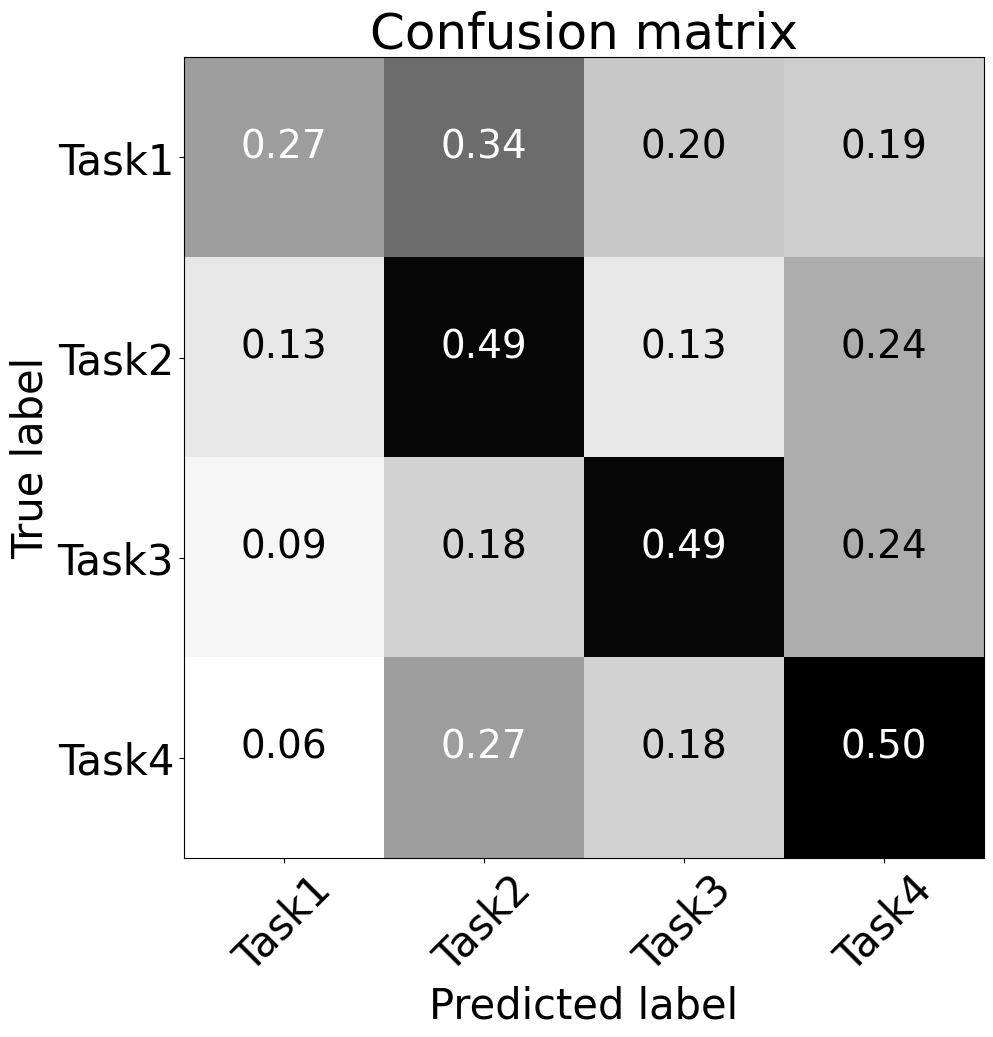

In [35]:
plot_confusion_matrix(cm, ['Task1', 'Task2', 'Task3', 'Task4'], normalize=True, title='Confusion matrix', cmap=plt.cm.Greys)